# Week 2 – Day 1: Dataset Readiness, Preprocessing & Feature Engineering

## 1) Introduction
Day 1 is about making raw data ready for machine learning. We focus on preprocessing, data quality, and careful feature engineering before model training.

## 2) Import libraries
We use `pandas`, `numpy`, and `matplotlib` for data handling and visualization, plus scikit-learn scaling tools.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler

%matplotlib inline

- `pandas`: table data operations.
- `numpy`: numerical operations and reproducible random generation.
- `matplotlib.pyplot`: plots for outliers and smoothing.
- `StandardScaler`: standardization.
- `MinMaxScaler`: normalization to [0,1].

### Shared dataset helper
To keep all three days connected, we use the same dataset path and generation logic.
- Day 1 creates and saves the dataset.
- Day 2 and Day 3 load it and regenerate it only if missing.


In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week2" / "house_energy_week2_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_house_energy_dataset(path, n_rows=150, seed=42):
    import numpy as np
    import pandas as pd

    rng = np.random.default_rng(seed)
    house_size_m2 = np.clip(rng.normal(135, 48, n_rows), 40, 460)
    bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1, n_rows)), 1, 8).astype(int)
    building_age_years = np.clip(rng.normal(32, 22, n_rows), 1, 120)
    city = rng.choice(["Berlin", "Munich", "Hamburg", "Cologne", "Leipzig"], size=n_rows, p=[0.25, 0.2, 0.2, 0.2, 0.15])
    heating_type = rng.choice(["Gas", "Electric", "Heat Pump", "District"], size=n_rows, p=[0.4, 0.25, 0.2, 0.15])
    insulation_grade = rng.choice(["A", "B", "C", "D"], size=n_rows, p=[0.2, 0.35, 0.3, 0.15])
    average_temperature_c = np.clip(rng.normal(10.5, 5, n_rows), -8, 24)

    insulation_effect = pd.Series(insulation_grade).map({"A": -1300, "B": -650, "C": 200, "D": 1050}).to_numpy()
    heating_effect = pd.Series(heating_type).map({"Heat Pump": -900, "District": -300, "Gas": 220, "Electric": 520}).to_numpy()
    city_effect = pd.Series(city).map({"Berlin": 120, "Munich": 270, "Hamburg": 170, "Cologne": 100, "Leipzig": -40}).to_numpy()
    noise = rng.normal(0, 450, n_rows)

    energy_consumption_kwh = (
        3500
        + 23 * house_size_m2
        + 15 * building_age_years
        + (14 - average_temperature_c) * 175
        + insulation_effect
        + heating_effect
        + city_effect
        + noise
    )
    energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

    df = pd.DataFrame({
        "house_size_m2": house_size_m2.round(1),
        "bedrooms": bedrooms,
        "building_age_years": building_age_years.round(1),
        "city": city,
        "heating_type": heating_type,
        "insulation_grade": insulation_grade,
        "average_temperature_c": average_temperature_c.round(1),
        "energy_consumption_kwh": energy_consumption_kwh.round(1),
    })

    for col in ["house_size_m2", "building_age_years", "average_temperature_c"]:
        idx = rng.choice(df.index, size=6, replace=False)
        df.loc[idx, col] = np.nan
    for col in ["city", "heating_type", "insulation_grade"]:
        idx = rng.choice(df.index, size=4, replace=False)
        df.loc[idx, col] = np.nan

    df.loc[4, ["house_size_m2", "energy_consumption_kwh"]] = [520, 35000]
    df.loc[58, ["building_age_years", "energy_consumption_kwh"]] = [145, 29000]
    df.loc[97, ["average_temperature_c", "energy_consumption_kwh"]] = [-20, 30500]

    duplicates = df.iloc[[12, 35]].copy()
    df = pd.concat([df, duplicates], ignore_index=True)
    df.to_csv(path, index=False)
    return df


## 3) Create and save the sample dataset
Generate and save the shared Week 2 dataset to `data/week2/house_energy_week2_sample.csv`.

In [3]:
df_generated = create_house_energy_dataset(DATASET_PATH, n_rows=150, seed=42)
print('Saved dataset to:', DATASET_PATH)
print('Generated shape:', df_generated.shape)

Saved dataset to: /Users/mehrdadjalali/Documents/SRH-Courses/Modules/Statistics and Machine Learning/Hands-on/Statistics-and-Machine-Learning/data/week2/house_energy_week2_sample.csv
Generated shape: (152, 8)


## 4) Load the dataset
Using `pd.read_csv()` mirrors real project workflow: save data, then load and explore it.

In [4]:
df = pd.read_csv(DATASET_PATH)
display(df.head())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,70.0,Hamburg,Gas,C,8.3,9320.4
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7355.9
2,171.0,3,51.0,Hamburg,Electric,C,2.0,11496.9
3,180.1,5,24.8,Berlin,District,C,NaN,8946.7
4,520.0,1,30.7,Berlin,Electric,C,7.7,35000.0


## 5) First look at the data
- `df.head()`: first rows preview.
- `df.shape`: dataset size.
- `df.info()`: dtypes and non-null counts.
- `df.describe()`: summary stats.
- `df.dtypes`: each column's type.
- `df.columns`: list of columns.

In [5]:
display(df.head())
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe())
print('\nDtypes:')
print(df.dtypes)
print('\nColumns:')
print(df.columns.tolist())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,70.0,Hamburg,Gas,C,8.3,9320.4
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7355.9
2,171.0,3,51.0,Hamburg,Electric,C,2.0,11496.9
3,180.1,5,24.8,Berlin,District,C,NaN,8946.7
4,520.0,1,30.7,Berlin,Electric,C,7.7,35000.0


Shape: (152, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           146 non-null    float64
 1   bedrooms                152 non-null    int64  
 2   building_age_years      146 non-null    float64
 3   city                    148 non-null    object 
 4   heating_type            147 non-null    object 
 5   insulation_grade        148 non-null    object 
 6   average_temperature_c   146 non-null    float64
 7   energy_consumption_kwh  152 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 9.6+ KB

Describe:


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,146.000000,152.000000,146.000000,146.000000,152.000000
mean,137.023288,3.822368,34.206164,10.156164,8082.386842
std,51.498706,1.619836,22.566949,5.524628,3745.102240
min,40.000000,1.000000,1.000000,-20.000000,3606.100000
25%,104.625000,3.000000,17.300000,7.750000,6333.075000
50%,137.100000,4.000000,34.700000,10.700000,7506.350000
75%,164.225000,5.000000,49.575000,13.250000,8714.500000
max,520.000000,8.000000,145.000000,21.700000,35000.000000



Dtypes:
house_size_m2             float64
bedrooms                    int64
building_age_years        float64
city                       object
heating_type               object
insulation_grade           object
average_temperature_c     float64
energy_consumption_kwh    float64
dtype: object

Columns:
['house_size_m2', 'bedrooms', 'building_age_years', 'city', 'heating_type', 'insulation_grade', 'average_temperature_c', 'energy_consumption_kwh']


## 6) Identify target and features
Target is what we predict. Features are inputs used for prediction.

In [6]:
target = 'energy_consumption_kwh'
X = df.drop(columns=[target])
y = df[target]

numerical_features = ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
categorical_features = ['city', 'heating_type', 'insulation_grade']

print('Target:', target)
print('X shape:', X.shape, '| y shape:', y.shape)
print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Target: energy_consumption_kwh
X shape: (152, 7) | y shape: (152,)
Numerical features: ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
Categorical features: ['city', 'heating_type', 'insulation_grade']


## 7) Check missing values
`isna().sum()` gives counts, and `isna().mean()*100` gives percentages.

In [7]:
missing_count = df.isna().sum()
missing_pct = df.isna().mean() * 100

display(missing_count)
display(missing_pct.round(2))

house_size_m2             6
bedrooms                  0
building_age_years        6
city                      4
heating_type              5
insulation_grade          4
average_temperature_c     6
energy_consumption_kwh    0
dtype: int64

house_size_m2             3.95
bedrooms                  0.00
building_age_years        3.95
city                      2.63
heating_type              3.29
insulation_grade          2.63
average_temperature_c     3.95
energy_consumption_kwh    0.00
dtype: float64

## 8) Handle missing values manually
- Mean: arithmetic average.
- Median: middle value (robust to outliers).
- Mode: most frequent value (good for categorical data).

In [8]:
df_manual = df.copy()
for col in numerical_features:
    df_manual[col] = df_manual[col].fillna(df_manual[col].median())
for col in categorical_features:
    df_manual[col] = df_manual[col].fillna(df_manual[col].mode()[0])
print(df_manual.isna().sum())

house_size_m2             0
bedrooms                  0
building_age_years        0
city                      0
heating_type              0
insulation_grade          0
average_temperature_c     0
energy_consumption_kwh    0
dtype: int64


## 9) Check duplicates
Use `duplicated()` to inspect repeated rows and `drop_duplicates()` to remove accidental duplicates.

In [9]:
print('Duplicate rows:', df_manual.duplicated().sum())
display(df_manual[df_manual.duplicated()])
df_no_dup = df_manual.drop_duplicates().copy()
print('Shape after drop_duplicates:', df_no_dup.shape)

Duplicate rows: 2


,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
150,138.2,6,70.4,Berlin,Heat Pump,D,2.8,10156.5
151,189.2,7,5.2,Hamburg,Gas,A,11.1,6904.9


Shape after drop_duplicates: (150, 8)


## 10) Inspect outliers
We inspect with summary stats, boxplots, and IQR flags. Not all outliers should be removed automatically.

,house_size_m2,building_age_years,energy_consumption_kwh
count,150.000000,150.000000,150.000000
mean,136.670667,34.178000,8076.409333
std,50.621275,21.935497,3765.082090
min,40.000000,1.000000,3606.100000
25%,106.600000,18.925000,6330.825000
50%,137.100000,34.700000,7506.350000
75%,160.975000,48.650000,8701.725000
max,520.000000,145.000000,35000.000000


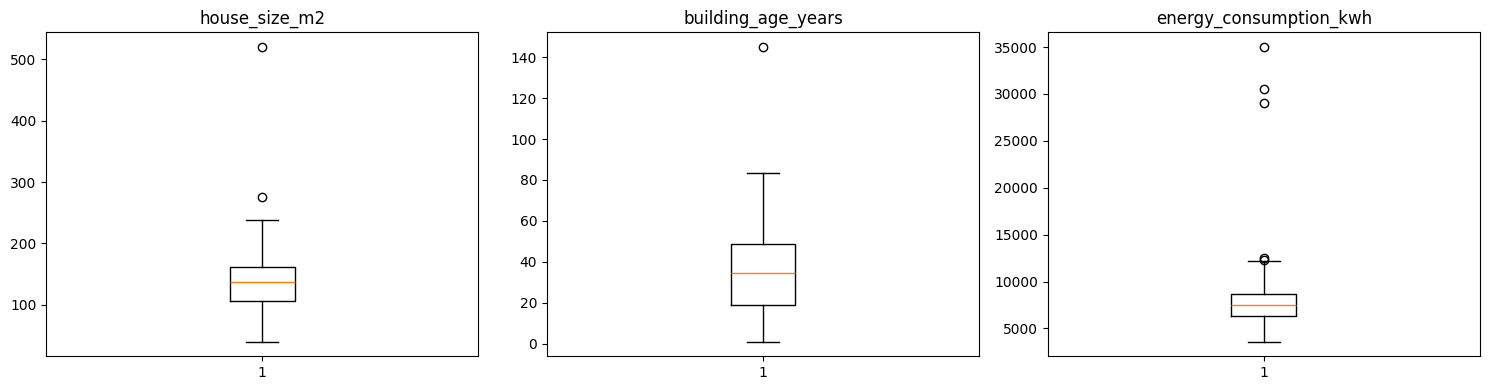

house_size_m2: 2 possible outliers | [25.04, 242.54]
building_age_years: 1 possible outliers | [-25.66, 93.24]
energy_consumption_kwh: 5 possible outliers | [2774.47, 12258.08]


In [10]:
display(df_no_dup[['house_size_m2','building_age_years','energy_consumption_kwh']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].boxplot(df_no_dup['house_size_m2']); axes[0].set_title('house_size_m2')
axes[1].boxplot(df_no_dup['building_age_years']); axes[1].set_title('building_age_years')
axes[2].boxplot(df_no_dup['energy_consumption_kwh']); axes[2].set_title('energy_consumption_kwh')
plt.tight_layout(); plt.show()

def iqr_flags(dataframe, col):
    q1 = dataframe[col].quantile(0.25)
    q3 = dataframe[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flags = (dataframe[col] < lower) | (dataframe[col] > upper)
    return flags, lower, upper

for col in ['house_size_m2','building_age_years','energy_consumption_kwh']:
    flags, lower, upper = iqr_flags(df_no_dup, col)
    print(f'{col}: {flags.sum()} possible outliers | [{lower:.2f}, {upper:.2f}]')

## 11) Noise and smoothing
Rolling mean smooths short-term variation and helps reveal trend direction.

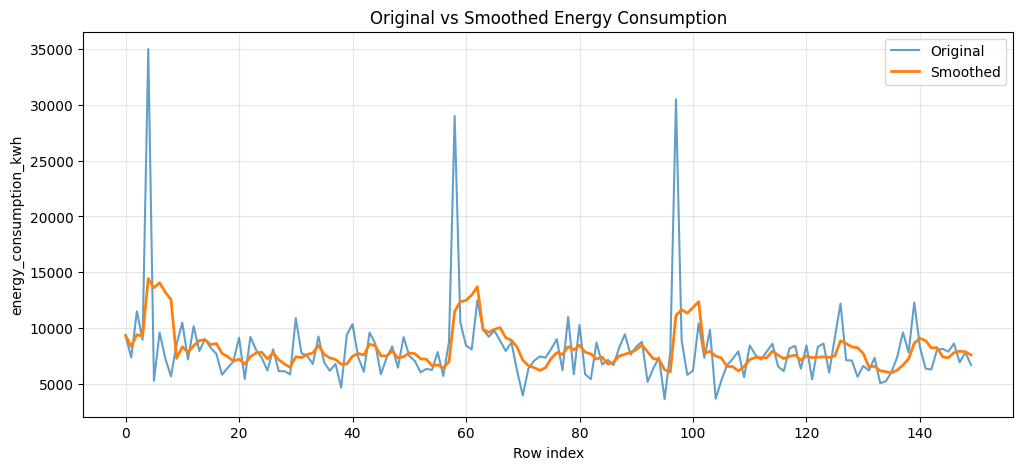

In [11]:
df_noise = df_no_dup.copy()
df_noise['energy_smoothed'] = df_noise['energy_consumption_kwh'].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12,5))
plt.plot(df_noise.index, df_noise['energy_consumption_kwh'], label='Original', alpha=0.7)
plt.plot(df_noise.index, df_noise['energy_smoothed'], label='Smoothed', linewidth=2)
plt.title('Original vs Smoothed Energy Consumption')
plt.xlabel('Row index'); plt.ylabel('energy_consumption_kwh')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 12) Encoding categorical variables
`pd.get_dummies()` performs one-hot encoding so categories become numeric columns.

In [12]:
encoded = pd.get_dummies(df_no_dup[categorical_features], drop_first=False)
print(encoded.shape)
display(encoded.head())

(150, 13)


,city_Berlin,city_Cologne,city_Hamburg,city_Leipzig,city_Munich,heating_type_District,heating_type_Electric,heating_type_Gas,heating_type_Heat Pump,insulation_grade_A,insulation_grade_B,insulation_grade_C,insulation_grade_D
0,False,False,True,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,True,False,True,False,False
2,False,False,True,False,False,False,True,False,False,False,False,True,False
3,True,False,False,False,False,True,False,False,False,False,False,True,False
4,True,False,False,False,False,False,True,False,False,False,False,True,False


## 13) Feature scaling
Formulas:
- `z = (x - mean) / standard deviation`
- `x_scaled = (x - x_min) / (x_max - x_min)`

In [13]:
num_data = df_no_dup[numerical_features].copy().fillna(df_no_dup[numerical_features].median())
std = StandardScaler()
mm = MinMaxScaler()
std_df = pd.DataFrame(std.fit_transform(num_data), columns=[f'{c}_std' for c in numerical_features])
mm_df = pd.DataFrame(mm.fit_transform(num_data), columns=[f'{c}_mm' for c in numerical_features])

display(num_data.describe().round(2))
display(std_df.describe().round(2))
display(mm_df.describe().round(2))

,house_size_m2,bedrooms,building_age_years,average_temperature_c
count,150.00,150.00,150.00,150.00
mean,136.67,3.79,34.18,10.22
std,50.62,1.60,21.94,5.42
min,40.00,1.00,1.00,-20.00
25%,106.60,3.00,18.92,8.00
50%,137.10,4.00,34.70,10.70
75%,160.98,5.00,48.65,13.08
max,520.00,8.00,145.00,21.70


,house_size_m2_std,bedrooms_std,building_age_years_std,average_temperature_c_std
count,150.00,150.00,150.00,150.00
mean,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.92,-1.75,-1.52,-5.60
25%,-0.60,-0.49,-0.70,-0.41
50%,0.01,0.13,0.02,0.09
75%,0.48,0.76,0.66,0.53
max,7.60,2.64,5.07,2.13


,house_size_m2_mm,bedrooms_mm,building_age_years_mm,average_temperature_c_mm
count,150.00,150.00,150.00,150.00
mean,0.20,0.40,0.23,0.72
std,0.11,0.23,0.15,0.13
min,0.00,0.00,0.00,0.00
25%,0.14,0.29,0.12,0.67
50%,0.20,0.43,0.23,0.74
75%,0.25,0.57,0.33,0.79
max,1.00,1.00,1.00,1.00


## 14) Basic feature engineering
We add four features for exploration.

`energy_per_m2` uses target information, so it is useful for exploration but should **not** be used as a model input feature (leakage risk).

In [14]:
df_feat = df_no_dup.copy()
df_feat['energy_per_m2'] = df_feat['energy_consumption_kwh'] / df_feat['house_size_m2']
df_feat['building_age_group'] = pd.cut(df_feat['building_age_years'], bins=[0,10,30,60,np.inf], labels=['New','Mid-age','Old','Very old'])
df_feat['size_temperature_interaction'] = df_feat['house_size_m2'] * df_feat['average_temperature_c']
df_feat['is_old_building'] = (df_feat['building_age_years'] > 40).astype(int)

display(df_feat[['energy_per_m2','building_age_group','size_temperature_interaction','is_old_building']].head())

,energy_per_m2,building_age_group,size_temperature_interaction,is_old_building
0,62.302139,Very old,1241.68,1
1,86.438308,New,-170.20,0
2,67.233333,Old,342.00,1
3,49.676291,Mid-age,1927.07,0
4,67.307692,Old,4004.00,0


## 15) Simple preprocessing plan
- [x] missing values handled
- [x] duplicates checked
- [x] outliers inspected
- [x] categorical variables encoded
- [x] numerical variables scaled
- [x] engineered features created carefully

## 16) Student TODO task
1. Create one additional engineered feature.
2. Explain why it may help.
3. Check missing or extreme values in that feature.

In [15]:
print('Week 2 Day 1 dataset readiness practical completed successfully.')

Week 2 Day 1 dataset readiness practical completed successfully.
